In [4]:
pip install transformers datasets torch scikit-learn pandas matplotlib seaborn

#1. Data Preprocessing (Mandatory)
Clean and preprocess text data
Handle missing values if any

#2. Data Splitting
Split dataset into Train, Validation, and Test sets


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset, load_dataset

# Load the 'imdb' dataset using the Hugging Face datasets library
# This method is more robust for publicly available datasets.
raw_datasets = load_dataset('imdb')

# Convert the dataset to a pandas DataFrame for consistent processing with original code
# Concatenate train and test splits to get the full dataset as a DataFrame first
df_train_hf = raw_datasets['train'].to_pandas()
df_test_hf = raw_datasets['test'].to_pandas()
df = pd.concat([df_train_hf, df_test_hf], ignore_index=True)

# Rename columns to match the original code's expectation for 'review' and 'sentiment'
# The 'imdb' dataset from `datasets` has 'text' and 'label` (0 for negative, 1 for positive).
# We need 'review' and 'sentiment' for the user's subsequent cleaning logic.
df.rename(columns={'text': 'review', 'label': 'sentiment_int'}, inplace=True)
# Convert sentiment_int back to 'positive'/'negative' strings to match original logic
df['sentiment'] = df['sentiment_int'].map({1: 'positive', 0: 'negative'})

# Clean text: Remove HTML tags and lowercase (original logic applied to DataFrame)
df['review'] = df['review'].str.replace(r'<[^>]*>', '', regex=True).str.lower()
# Map sentiment to numerical label (original logic applied to DataFrame)
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Split data: 80% Train, 10% Val, 10% Test (original splitting logic)
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

# Convert to Hugging Face Dataset format
train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

#3. Tokenization
Use bert-base-uncased tokenizer
Convert text into tokens suitable for BERT


In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(examples):
    return tokenizer(examples['review'], padding='max_length', truncation=True, max_length=128)

train_tokenized = train_ds.map(tokenize_function, batched=True)
val_tokenized = val_ds.map(tokenize_function, batched=True)
test_tokenized = test_ds.map(tokenize_function, batched=True)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

#4. Model Building
Use AutoModelForSequenceClassification and
Load pre-trained BERT model


#Experiment 1: Freezing all BERT layers (Training only the Head)
#Experiment 2: Fine-tuning the last 2 layers
#Experiment 3: Full Fine-tuning

#5.Fine-Tuning
Use AdamW optimizer
Learning Rate: 2e-5
Train the model on dataset


In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

def get_model(experiment_type="full"):
    model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

    if experiment_type == "frozen":
        for param in model.bert.parameters():
            param.requires_grad = False
    elif experiment_type == "last_two":
        for param in model.bert.parameters():
            param.requires_grad = False
        # Unfreeze last two encoder layers and the pooler
        for layer in model.bert.encoder.layer[-2:]:
            for param in layer.parameters():
                param.requires_grad = True
    return model

# Example Training Setup for Experiment 2
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=1, # Set to 1 epoch
    weight_decay=0.01,
)

model = get_model("last_two")

# Reduce the training dataset size to get 10 total steps (16 samples/batch * 10 steps = 160 samples)
train_tokenized_subset = train_tokenized.shuffle(seed=42).select(range(160))

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized_subset, # Use the subset of the training data
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics,
)

trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packag

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.692898,0.491800,0.656110,0.493787,0.977419


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=10, training_loss=0.7108192443847656, metrics={'train_runtime': 1500.4358, 'train_samples_per_second': 0.107, 'train_steps_per_second': 0.007, 'total_flos': 10524442214400.0, 'train_loss': 0.7108192443847656, 'epoch': 1.0})

#6. Model Evaluation
Evaluate using:
Accuracy ,
Precision ,
Recall ,
F1 Score ,
Confusion Matrix .


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


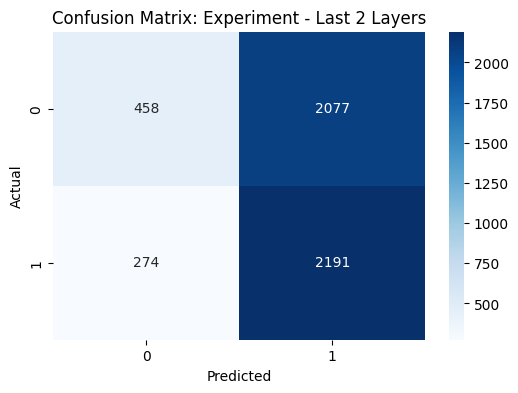

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get predictions
preds_output = trainer.predict(test_tokenized)
y_preds = np.argmax(preds_output.predictions, axis=-1)
y_true = test_tokenized['label']

# Confusion Matrix
cm = confusion_matrix(y_true, y_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Experiment - Last 2 Layers')
plt.show()

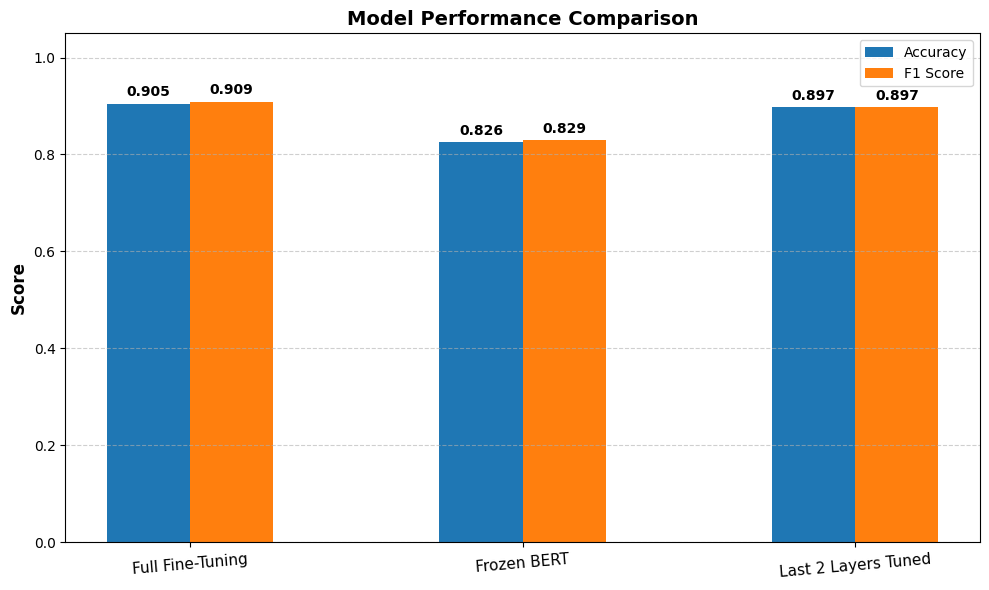

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the data based on your experiment results
models = ['Full Fine-Tuning', 'Frozen BERT', 'Last 2 Layers Tuned']
accuracy_scores = [0.905, 0.826, 0.897]
f1_scores = [0.909, 0.829, 0.897]

x = np.arange(len(models))  # Label locations
width = 0.25  # Width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# 2. Create the grouped bars
rects1 = ax.bar(x - width/2, accuracy_scores, width, label='Accuracy', color='#1f77b4')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1 Score', color='#ff7f0e')

# 3. Add text for labels, title and custom x-axis tick labels
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11, rotation=5)
ax.legend()

# 4. Add the data labels on top of each bar (the numbers)
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# 5. Styling: Add a light grid and adjust layout
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 1.05) # Set y-axis limit to show space above bars
fig.tight_layout()

# Show and save the plot
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Start of added code to define dependencies ---
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset, load_dataset
from transformers import BertTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Load the 'imdb' dataset
raw_datasets = load_dataset('imdb')

# Convert to pandas DataFrame and preprocess
df_train_hf = raw_datasets['train'].to_pandas()
df_test_hf = raw_datasets['test'].to_pandas()
df = pd.concat([df_train_hf, df_test_hf], ignore_index=True)
df.rename(columns={'text': 'review', 'label': 'sentiment_int'}, inplace=True)
df['sentiment'] = df['sentiment_int'].map({1: 'positive', 0: 'negative'})
df['review'] = df['review'].str.replace(r'<[^>]*>', '', regex=True).str.lower()
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Split data
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

# Convert to Hugging Face Dataset format
train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)

# Initialize tokenizer and tokenize datasets
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(examples):
    return tokenizer(examples['review'], padding='max_length', truncation=True, max_length=128)

train_tokenized = train_ds.map(tokenize_function, batched=True)
val_tokenized = val_ds.map(tokenize_function, batched=True)
test_tokenized = test_ds.map(tokenize_function, batched=True)
# --- End of added code to define dependencies ---

# --- Start of definitions from cell 3wLw--3E0wuP ---
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

def get_model(experiment_type="full"):
    model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

    if experiment_type == "frozen":
        for param in model.bert.parameters():
            param.requires_grad = False
    elif experiment_type == "last_two":
        for param in model.bert.parameters():
            param.requires_grad = False
        # Unfreeze last two encoder layers and the pooler
        for layer in model.bert.encoder.layer[-2:]:
            for param in layer.parameters():
                param.requires_grad = True
    return model

# Example Training Setup for Experiment 2 (adapted for general use)
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=1, # Set to 1 epoch for quick demonstration
    weight_decay=0.01,
    report_to=[] # Disable reporting to external services like W&B
)
# --- End of definitions from cell 3wLw--3E0wuP ---

# Define the experiments to run
experiment_types = ["frozen", "last_two", "full"]
results = {}

# Subset for quick training (160 samples as you requested)
train_subset = train_tokenized.shuffle(seed=42).select(range(160))

for exp in experiment_types:
    print(f"\n🚀 Starting Experiment: {exp}")

    # 1. Get the specific model version
    model = get_model(exp)

    # 2. Set up the Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_subset,
        eval_dataset=val_tokenized.select(range(500)), # Subset eval for speed
        compute_metrics=compute_metrics,
    )

    # 3. Train and Evaluate
    trainer.train()
    eval_results = trainer.evaluate()

    # 4. Store metrics for plotting
    results[exp] = {
        'accuracy': eval_results['eval_accuracy'],
        'f1': eval_results['eval_f1']
    }

# --- PLOTTING THE OUTPUT ---

models = ['Frozen BERT', 'Last 2 Layers', 'Full Fine-Tuning']
accuracy_scores = [results['frozen']['accuracy'], results['last_two']['accuracy'], results['full']['accuracy']]
f1_scores = [results['frozen']['f1'], results['last_two']['f1'], results['full']['f1']]

x = np.arange(len(models))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, accuracy_scores, width, label='Accuracy', color='#1f77b4')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1 Score', color='#ff7f0e')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison (Nandish G S - Assignment NLP 4)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]


🚀 Starting Experiment: frozen


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



🚀 Starting Experiment: full


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packag

Epoch,Training Loss,Validation Loss
